# Лабораторная работа №4

ФИО:   
Группа:

Отправлять можно следующими способами:
1. Запушить этот ноутбук в GitHub в репозиторий, где у вас лежат ноутбуки с лабами

Deadlines:
- Занятие №8 в семестре (Занятие №4 очное)

Что необходимо сделать:  
- Обучить различные модели глубокого обучения на имеющихся данных  

---
## Читайте задание внимательно

Исходные данные:
1. В [табличке](https://docs.google.com/spreadsheets/d/1k2MYXEp_OVQrink_XRC1PwoM0ZuNMeNz4VTWY7cI3hE/edit?usp=sharing) необходимо узнать название своего датасета
2. Скачать нужны вам данные можно в [Google Drive](https://drive.google.com/drive/folders/1Phm-Fq1GL-VX7NS-DCEMRh_Fo1wU7DQ9?usp=sharing)
  
---
Теперь по пунктам, что я от вас жду:  
1. Загрузить необходимые данные к себе и считать (read) их в переменную.
2. Понять, у вас задача классификации (бинарной или многоклассовой) или регрессии.
3. Сделать предобработку данных:  
     1. Разделить выборку на тренировочную (train) и тестовую (test). _Обратите внимание, что обучать скейлеры и определять, какими значениями вы будете заполнять пропуски, вы будете на train выборке, а применять и на train, и на test_.
     2. Проверить пропуски в данных. Если они есть, заполнить одной из стратегий, предложенных в ноутбуке для семинара №3. P.S. Для численных и категориальных переменных будут разные стратегии.
     3. Отнормировать численные переменные (`StandardScaler`, `MinMaxScaler`).
     4. Закодировать категориальные признаки по одной из стратегий.
4. Оформить данные в виде класса `Dataset` из библиотеки `torch` (как мы это делали на семинаре), а затем засунуть в `Dataloader` (тоже делали на семинаре).
5. Обучить на тренировочном множестве:
     1. Очень простую однослойную нейросеть с оптимизатором `SGD` ([link](https://pytorch.org/docs/stable/optim.html)).
     2. Нейросеть посложнее (с 1 скрытым слоем) с оптимизатором `Adam` ([link](https://pytorch.org/docs/stable/optim.html)).
     3. Нейросеть еще сложнее (с 3+ скрытыми слоями) с оптимизатором `Adam` ([link](https://pytorch.org/docs/stable/optim.html)).
6. Посчитайте loss на train и test множествах, в зависимости от эпохи обучения. Провизуализируйте это с помощью библиотеки `matplotlib` (выйдет так называемая **learning curve**, кривая обучения модели).
6. Посчитайте метрики на train и test множествах:
     1. Для задачи классификации -- Accuracy
     2. Для задачи регрессии -- MAE
7. Сравните метрики относительно train/test, так и относительно разных моделей. Ответьте на следующие вопросы:
     1. Какая модель справилась лучше с поставленной задачей?
     2. Имеет ли место переобучение?
     3. Имеет ли место недообучение?
     4. Как можно улучшить метрики моделей?

---
P.S.  
Просьба -- делать каждое задание в отдельных ячейках и с отдельными заголовками (как пункт 1 и 2 в этом ноутбуке) типа  
- Заголовок
- Ячейки с кодом
- Другой заголовок
- Другие ячейки с кодом

P.S.S.  
Если вам повезло с многоклассовой классификацией, у вас не будет проблем, просто нужно будет поставить необходимое количество нейронов на выходе вашей нейросети.

## 1. Пример импорта данных. Грузим данные

In [99]:
from torch.utils.data import Dataset
import torch
import kagglehub
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


class SleepDisorderDataset(Dataset): # Создадим класс датасета
  def __init__(self, X: pd.DataFrame, y: pd.DataFrame):
    self.X = torch.from_numpy(X.values).float()
    self.y = torch.from_numpy(y.values).long()

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    return (self.X[index], self.y[index])


## 2. Понимаем, какая перед нами задача

## 3. Делаем предобработку данных

In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


class BaseNet(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_layers):
        super(BaseNet, self).__init__()
        layers = []

        if hidden_layers:
            prev_dim = input_dim
            for neurons in hidden_layers:
                layers.append(nn.Linear(prev_dim, neurons))
                layers.append(nn.ReLU())
                prev_dim = neurons
            layers.append(nn.Linear(prev_dim, output_dim))
        else:
            layers.append(nn.Linear(input_dim, output_dim))

        layers.append(nn.Softmax(dim=1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class NoHiddenLayersNet(BaseNet):
  def __init__(self, input_dim, output_dim):
      super(NoHiddenLayersNet, self).__init__(
          input_dim,
          output_dim,
          hidden_layers=[]
      )


class OneHiddenLayerNet(BaseNet):
  def __init__(self, input_dim, output_dim):
      super(OneHiddenLayerNet, self).__init__(
          input_dim,
          output_dim,
          hidden_layers=[64]
      )

class ManyLayersNet(BaseNet):
  def __init__(self, input_dim, output_dim):
      super(ManyLayersNet, self).__init__(
          input_dim,
          output_dim,
          hidden_layers=[128, 64, 32, 16]
      )

In [101]:
def preprocess(pd_ds):
    pd_ds['upper'], pd_ds['lower'] = (
        pd_ds['Blood Pressure'].str.split('/', expand=True)[0],
        pd_ds['Blood Pressure'].str.split('/', expand=True)[1]
    )
    pd_ds = pd_ds.drop('Blood Pressure', axis=1)
    pd_ds = pd_ds.drop('Person ID', axis=1)

    numeric_features = ['Age', 'Sleep Duration',
                        'Heart Rate', 'Daily Steps', 'upper', 'lower']

    categorical_features = [
        'Occupation','Quality of Sleep','Gender',
        'Physical Activity Level', 'Stress Level', 'BMI Category',
        'Sleep Disorder'
    ]

    pd_ds[numeric_features] = MinMaxScaler().fit_transform(
        pd_ds[numeric_features]
    )

    for cat in categorical_features:
      le = LabelEncoder()
      le.fit(pd_ds[cat])
      pd_ds[cat] = le.transform(pd_ds[cat])

    return train_test_split(
      pd_ds.drop('Sleep Disorder', axis=1), pd_ds['Sleep Disorder'],
      test_size=0.25, random_state=42
    )



In [102]:
from torch.utils.data import DataLoader


path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
pd_ds = pd.read_csv(path  + '/Sleep_health_and_lifestyle_dataset.csv')

X_train, X_test, y_train, y_test = preprocess(pd_ds)


test_ds = SleepDisorderDataset(X_test, y_test)
train_ds = SleepDisorderDataset(X_train, y_train)

train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=64, shuffle=True)

input_dim = X_test.shape[1] # кол-во фичей
output_dim = 3 # кол-во классов




In [103]:
def train_model(model, optimizer, train_loader, test_loader, epochs=100):
    criterion = nn.CrossEntropyLoss()
    train_loss_history = []
    test_loss_history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_loss_history.append(train_loss)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item()

        test_loss /= len(test_loader)
        test_loss_history.append(test_loss)

        # Вывод метрик на текущей эпохе
        print(f"Epoch {epoch + 1}/{epochs}: Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

    return train_loss_history, test_loss_history




Epoch 1/100: Train Loss: 1.0441, Test Loss: 1.0367
Epoch 2/100: Train Loss: 1.0058, Test Loss: 1.0249
Epoch 3/100: Train Loss: 1.0096, Test Loss: 0.9971
Epoch 4/100: Train Loss: 1.0000, Test Loss: 1.0098
Epoch 5/100: Train Loss: 0.9779, Test Loss: 0.9798
Epoch 6/100: Train Loss: 0.9755, Test Loss: 0.9789
Epoch 7/100: Train Loss: 0.9528, Test Loss: 1.0111
Epoch 8/100: Train Loss: 0.9541, Test Loss: 0.9721
Epoch 9/100: Train Loss: 0.9506, Test Loss: 0.9734
Epoch 10/100: Train Loss: 0.9455, Test Loss: 0.9622
Epoch 11/100: Train Loss: 0.9301, Test Loss: 0.9554
Epoch 12/100: Train Loss: 0.9186, Test Loss: 0.9475
Epoch 13/100: Train Loss: 0.9178, Test Loss: 0.9720
Epoch 14/100: Train Loss: 0.9294, Test Loss: 0.9704
Epoch 15/100: Train Loss: 0.9223, Test Loss: 0.9500
Epoch 16/100: Train Loss: 0.9313, Test Loss: 0.9485
Epoch 17/100: Train Loss: 0.9168, Test Loss: 0.9423
Epoch 18/100: Train Loss: 0.9025, Test Loss: 0.9466
Epoch 19/100: Train Loss: 0.9053, Test Loss: 0.9299
Epoch 20/100: Train L

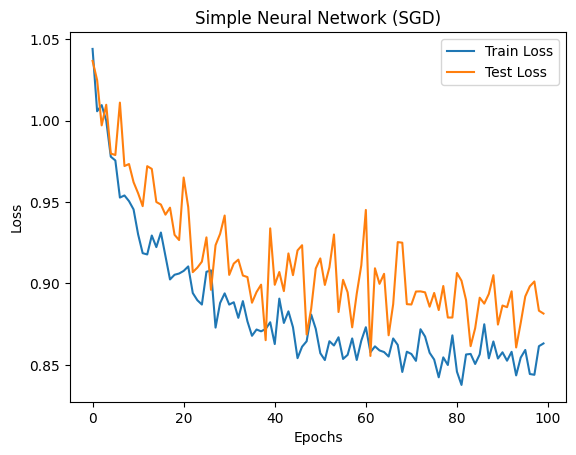

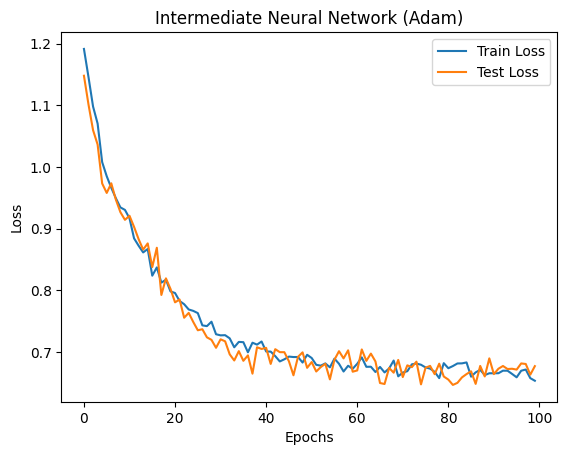

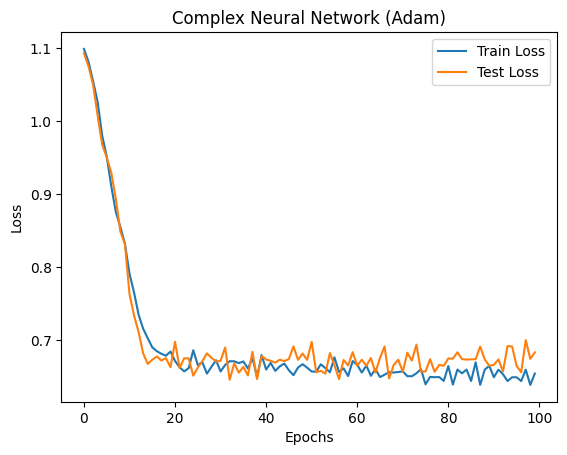

In [104]:
input_dim, output_dim = X_train.shape[1], len(set(y_train))

zero_model = NoHiddenLayersNet(input_dim, output_dim)
zero_optimizer = optim.SGD(zero_model.parameters(), lr=0.01)
zero_train_loss, zero_test_loss = train_model(zero_model, zero_optimizer, train_dataloader, test_dataloader)

one_model = OneHiddenLayerNet(input_dim, output_dim)
one_optimizer = optim.Adam(one_model.parameters(), lr=0.001)
one_train_loss, one_test_loss = train_model(one_model, one_optimizer, train_dataloader, test_dataloader)

many_model = ManyLayersNet(input_dim, output_dim)
many_optimizer = optim.Adam(many_model.parameters(), lr=0.001)
many_train_loss, many_test_loss = train_model(many_model, many_optimizer, train_dataloader, test_dataloader)



def plot_learning_curves(train_loss, test_loss, title):
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_learning_curves(zero_train_loss, zero_test_loss, "Simple Neural Network (SGD)")
plot_learning_curves(one_train_loss, one_test_loss, "Intermediate Neural Network (Adam)")
plot_learning_curves(many_train_loss, many_test_loss, "Complex Neural Network (Adam)")


In [105]:
import torch

def calculate_accuracy(model, data_loader):
    model.eval()
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)

            _, predicted = torch.max(outputs, 1)

            # Считаем количество правильных предсказаний
            correct_predictions += (predicted == y_batch).sum().item()
            total_predictions += y_batch.size(0)

    accuracy = correct_predictions / total_predictions
    return accuracy

models = [zero_model, one_model, many_model]

for model in models:
  train_accuracy = calculate_accuracy(model, train_dataloader)
  test_accuracy = calculate_accuracy(model, test_dataloader)

  print(f"Train Accuracy for {type(model)}: {train_accuracy * 100:.2f}%")
  print(f"Test Accuracy for {type(model)}: {test_accuracy * 100:.2f}%")


Train Accuracy for <class '__main__.NoHiddenLayersNet'>: 72.50%
Test Accuracy for <class '__main__.NoHiddenLayersNet'>: 70.21%
Train Accuracy for <class '__main__.OneHiddenLayerNet'>: 88.93%
Test Accuracy for <class '__main__.OneHiddenLayerNet'>: 88.30%
Train Accuracy for <class '__main__.ManyLayersNet'>: 90.00%
Test Accuracy for <class '__main__.ManyLayersNet'>: 88.30%
